# Problem 2: Plotting Data

In Problem #1 we implemented code that generates a CVS file of hourly Ticker data for past 5 days for Stocks META, AAPL, AMZN, NFLX, GOOG   
We now need to plot the Close price data for each of these five stocks

## Reading wide format CSV with multi-level columns 
I had struggles with reading this CSV format where multiple stock's data is spread across multiple columns horizontally.  
  
Row 1: Ticker symbols (META, AMZN, AAPL, GOOG, NFLX) - each repeated 5 times  
Row 2: Data types (Open, High, Low, Close, Volume) - repeated for each stock  
Row 3+: DateTime stamps with the actual price/volume data  


https://medium.com/@gotashirato/how-to-import-csv-file-with-multi-level-columns-python-basics-and-a-question-b67cbbbc174d   
https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html  
https://stackoverflow.com/questions/21318865/read-multi-index-on-the-columns-from-csv-file  


I wanted to simplify the dataframe before plotting


In [15]:
import pandas as pd
import glob

# Find the CSV file (should only be one in the data folder)
csv_file = glob.glob("data/*.csv")[0]

# Read the CSV file with 3 Headers
df = pd.read_csv(csv_file, header=[0, 1, 2], index_col=0)

# Extract GOOG Close data
goog_close = df[('GOOG', 'Close')].reset_index()
goog_close.columns = ['Date', 'Close']

# Convert Date to datetime
goog_close['Date'] = pd.to_datetime(goog_close['Date'])

print(goog_close)

                        Date       Close
0  2025-11-17 14:30:00+00:00  290.899994
1  2025-11-17 15:30:00+00:00  288.450012
2  2025-11-17 16:30:00+00:00  289.011810
3  2025-11-17 17:30:00+00:00  286.299988
4  2025-11-17 18:30:00+00:00  285.619904
5  2025-11-17 19:30:00+00:00  285.309998
6  2025-11-17 20:30:00+00:00  285.600006
7  2025-11-18 14:30:00+00:00  282.329987
8  2025-11-18 15:30:00+00:00  286.817993
9  2025-11-18 16:30:00+00:00  284.890015
10 2025-11-18 17:30:00+00:00  288.309998
11 2025-11-18 18:30:00+00:00  288.140015
12 2025-11-18 19:30:00+00:00  287.299988
13 2025-11-18 20:30:00+00:00  284.899994
14 2025-11-19 14:30:00+00:00  301.667206
15 2025-11-19 15:30:00+00:00  296.529999
16 2025-11-19 16:30:00+00:00  294.459991
17 2025-11-19 17:30:00+00:00  293.320007
18 2025-11-19 18:30:00+00:00  294.109985
19 2025-11-19 19:30:00+00:00  295.720093
20 2025-11-19 20:30:00+00:00  293.000000
21 2025-11-20 14:30:00+00:00  304.820007
22 2025-11-20 15:30:00+00:00  300.279999
23 2025-11-20 16

/tmp/ipykernel_19430/4078340175.py:11: PerformanceWarning: indexing past lexsort depth may impact performance.
  goog_close = df[('GOOG', 'Close')].reset_index()


***
# Processing CSV files  
The archiving of csv files ensures that there should only a be a single csv file in ./data/ folder at any given time.  
But, if other csv file are within that folder (for whatever reason) ... we need to ensure that latest file is selected.  

To extract a list of path names that match pathname pattern I used the glob module    
https://docs.python.org/3/library/glob.html    

**I much prefered to augment the use of os module with the glob module for extracting all csv files in a folder**.  
os Module does not allow the use of wildcard patterns (e.g. *.csv), but glob module does allow these wildcards. 


In [9]:
#Test use of glob module for extracting latest file
import glob
import os
csv_dir = "./data/archive"
cvs_filepath = os.path.join(csv_dir, "*.csv" )
csv_files = glob.glob(cvs_filepath)

# Get the most recently modified file
if csv_files:
    csv_files.sort(reverse=True)
    latest_file =csv_files[0]
    print(f"Latest file: {latest_file}")

Latest file: ./data/archive/20251123-195022.csv


## Plotting Data  
Open the latest CSV file in the data folder and, on one plot, plots the Close prices for each of the five stocks.   
Save as a PNG file in the ../data/plots/ folder.  
https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html#matplotlib.pyplot.savefig   
https://www.geeksforgeeks.org/python/matplotlib-pyplot-savefig-in-python/  
https://www.youtube.com/watch?v=I6tvyasOxaQ   
  

**Note:** I did not like the use of pandas.plot(), and I wanted to keep plotting to be done a by **pyplot** module for more flexibility 

/tmp/ipykernel_9797/3201838231.py:32: PerformanceWarning: indexing past lexsort depth may impact performance.
  plt.plot(df_stock.index, df_stock[(stock,'Close')], marker='o', label=stock)


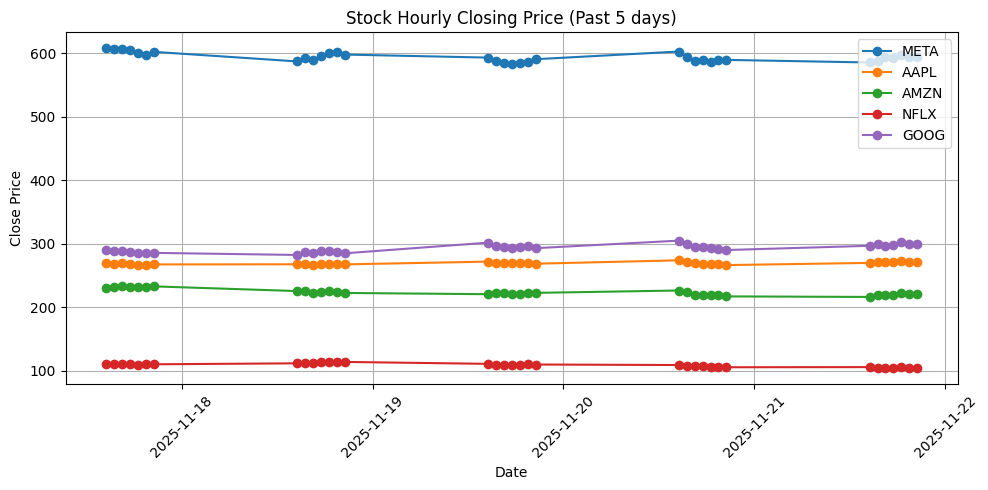

In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import glob
from datetime import datetime
import os

# Find the CSV file (should only be one in the data folder)
csv_dir = "./data/"
plot_dir = "./data/plots/"

def readCSV(file_path:str):
    latest_file = None
    cvs_filepath = os.path.join(file_path, "*.csv" )
    csv_files = glob.glob(cvs_filepath)
    # Get the most recently modified file
    if csv_files:
        csv_files.sort(reverse=True)
        latest_file =csv_files[0]
    
    # Read the CSV file with 3 Headers
    if latest_file:
        df = pd.read_csv(latest_file, header=[0, 1, 2], index_col=0, parse_dates=True)
    return df

def plot_data(df_stock:pd.DataFrame):
    filename = datetime.now().strftime("%Y%m%d-%H%M%S") + ".png"
    plot_filepath = os.path.join(plot_dir, filename )

    plt.figure(figsize=(10,5))
    for stock in ['META', 'AAPL', 'AMZN', 'NFLX', 'GOOG']:
        plt.plot(df_stock.index, df_stock[(stock,'Close')], marker='o', label=stock)
    plt.title('Stock Hourly Closing Price (Past 5 days)')
    plt.xlabel('Date')
    plt.ylabel('Close Price')
    plt.grid(True)
    plt.legend()

    # Format the x-axis dates
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))  # Show every Day
    plt.xticks(rotation=45)

    plt.tight_layout()
    # Save the figure before showing it
    plt.savefig(plot_filepath, dpi=300, bbox_inches='tight')
    plt.show()

df_stocks = readCSV(csv_dir)
plot_data(df_stocks)

***
## Problems with Plot    
No Error Handling  
There seems to issues with "gaps" in timescales when market is closed  
There is also very different prices for the different stocks.  
* AAPL, AMZN, GOOG are less than 300  
* META is trading at almost 600  
* NFLX is trading at 120 +  